In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [2]:
df = pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\samplesuperstore.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

sales = df.groupby('Order Date')['Sales'].sum().reset_index()
sales.head()


,Order Date,Sales
0,2023-01-03,16.448
1,2023-01-04,288.060
2,2023-01-05,19.536
3,2023-01-06,4407.100
4,2023-01-07,87.158


In [5]:
sales = sales.set_index('Order Date')
sales = sales.asfreq('D')
sales['Sales'] = sales['Sales'].fillna(0)

sales.head()


,Sales
Order Date,
2023-01-03,16.448
2023-01-04,288.060
2023-01-05,19.536
2023-01-06,4407.100
2023-01-07,87.158


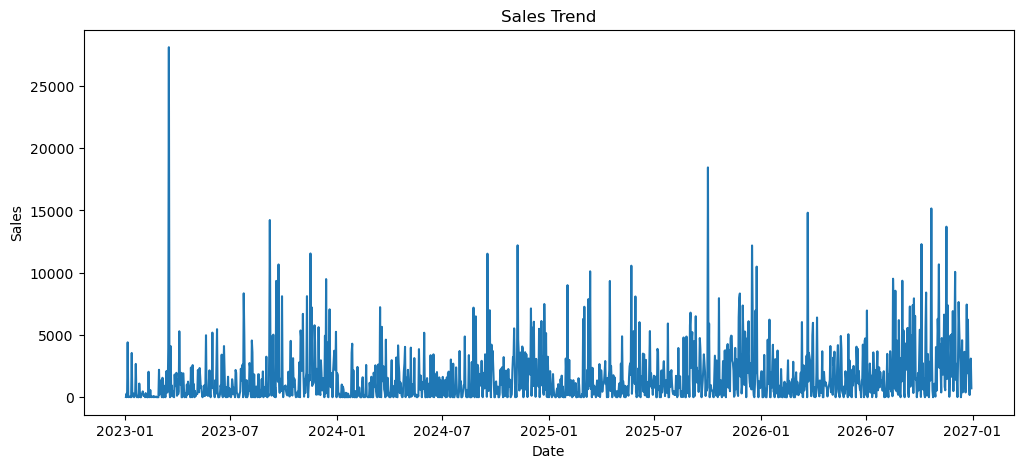

In [6]:
plt.figure(figsize=(12,5))
plt.plot(sales['Sales'])
plt.title('Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_2620\1049610922.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales['Sales'].resample('M').sum()


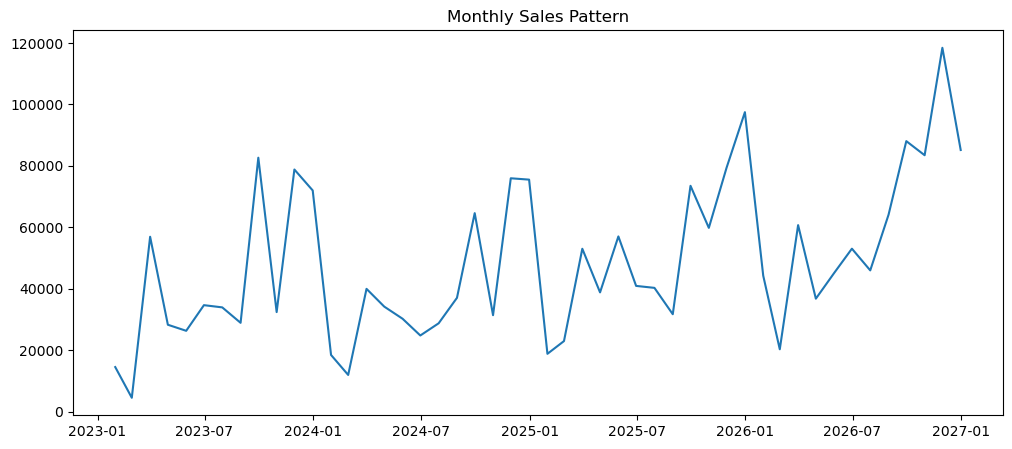

In [7]:
monthly_sales = sales['Sales'].resample('M').sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title('Monthly Sales Pattern')
plt.show()


In [8]:
train = sales.iloc[:-30]
test = sales.iloc[-30:]

print("Train Size:", len(train))
print("Test Size:", len(test))


Train Size: 1428
Test Size: 30


In [9]:
model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal=None
)

fit_model = model.fit()
forecast = fit_model.forecast(30)


In [10]:
mae = mean_absolute_error(test['Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['Sales'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 2226.602219652194
RMSE: 2611.734288770946


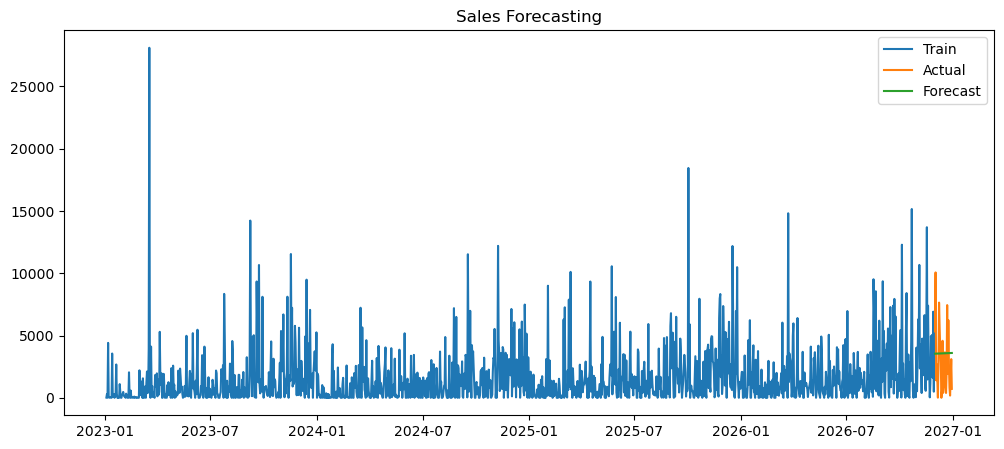

In [11]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title('Sales Forecasting')
plt.show()


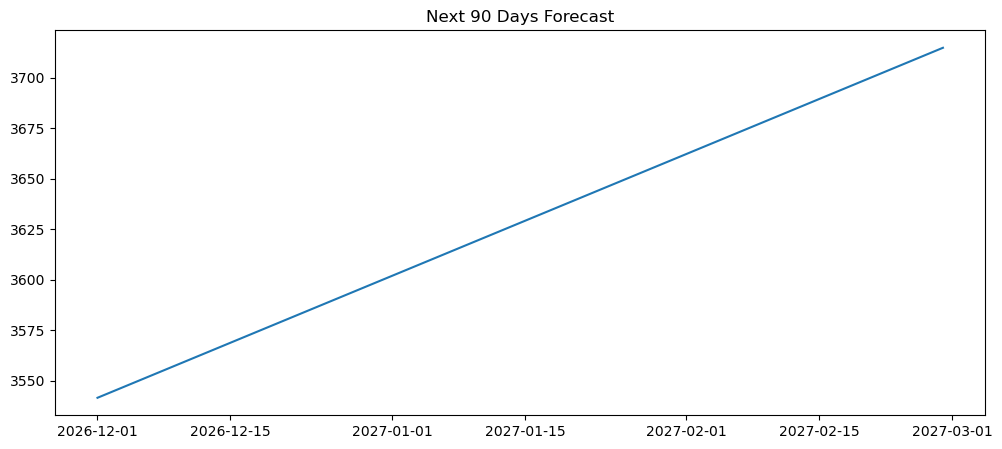

2026-12-01    3541.562504
2026-12-02    3543.508822
2026-12-03    3545.455140
2026-12-04    3547.401458
2026-12-05    3549.347776
Freq: D, dtype: float64

In [12]:
future_forecast = fit_model.forecast(90)

plt.figure(figsize=(12,5))
plt.plot(future_forecast)
plt.title('Next 90 Days Forecast')
plt.show()

future_forecast.head()


In [13]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (10194, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Statistical Summary:


,Row ID,Order Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,619.906839,2.228317,0.206249,232.465115


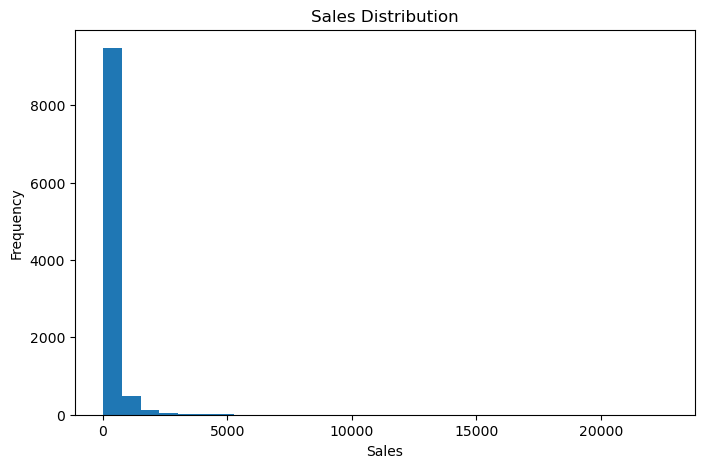

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

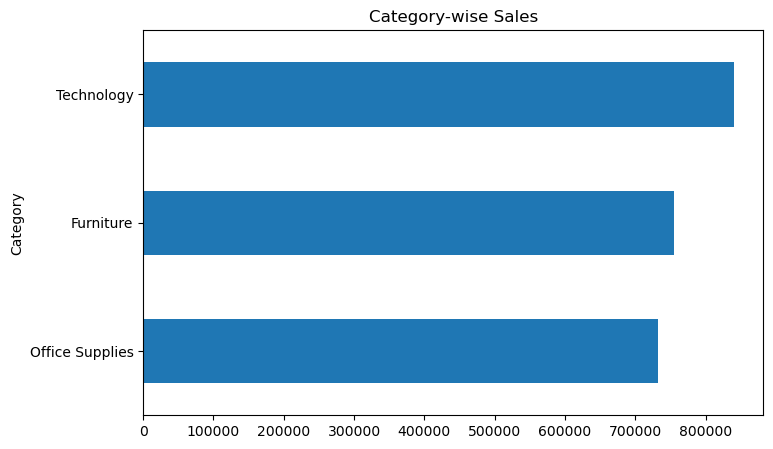

In [16]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.sort_values().plot(kind='barh')
plt.title("Category-wise Sales")
plt.show()

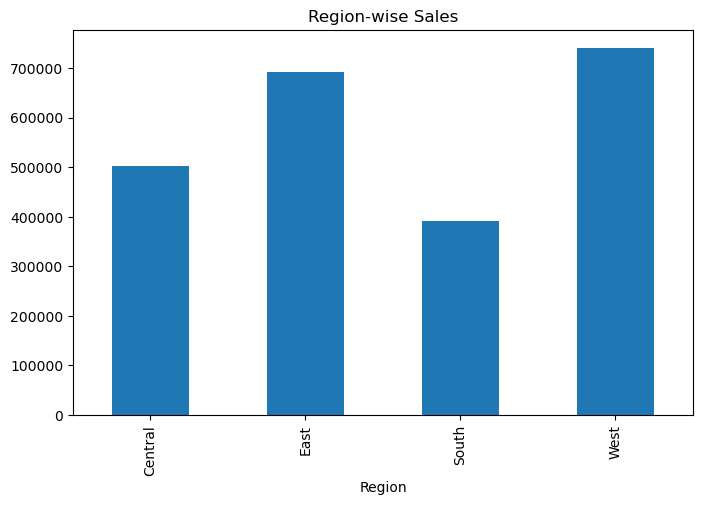

In [17]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Region-wise Sales")
plt.show()

C:\Users\hi\AppData\Local\Temp\ipykernel_2620\2963424893.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sales['Sales'].resample('M').sum()


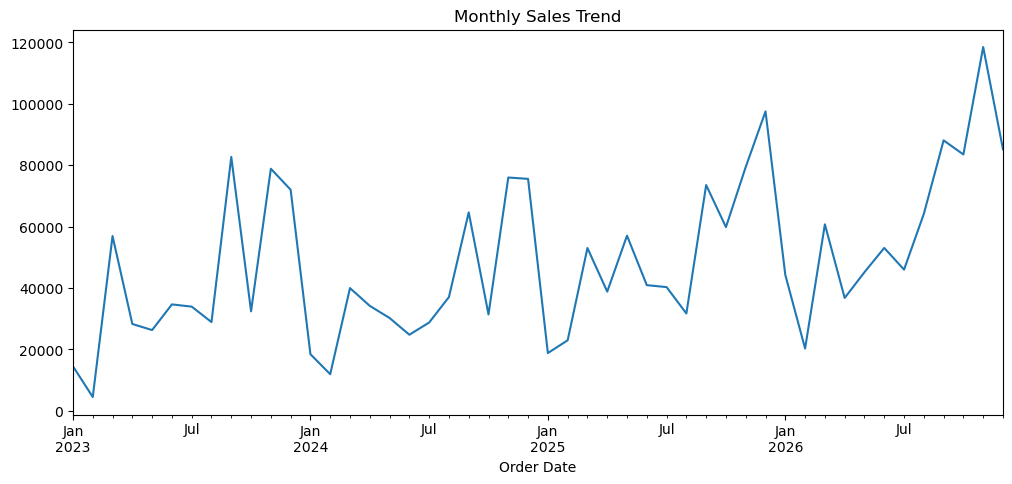

In [18]:
monthly = sales['Sales'].resample('M').sum()

monthly.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.show()

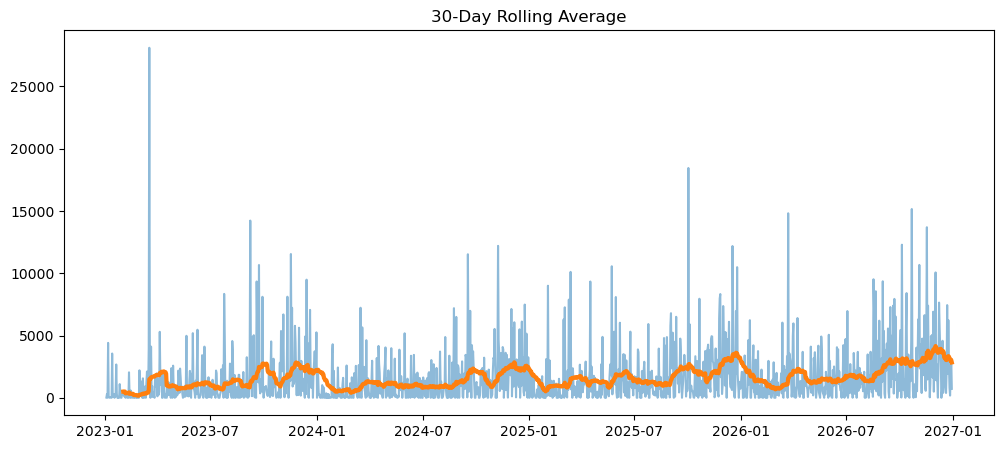

In [19]:
sales['Rolling_30'] = sales['Sales'].rolling(30).mean()

plt.figure(figsize=(12,5))
plt.plot(sales['Sales'], alpha=0.5)
plt.plot(sales['Rolling_30'], linewidth=3)
plt.title("30-Day Rolling Average")
plt.show()

In [22]:
mask = test['Sales'] != 0
actuals = test['Sales'][mask]
preds = forecast[mask]


mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
accuracy = 100 - mape

print("MAPE:", round(mape, 2), "%")
print("Forecast Accuracy:", round(accuracy, 2), "%")

MAPE: 1360.62 %
Forecast Accuracy: -1260.62 %


In [23]:
print("Average Daily Sales:", sales['Sales'].mean())
print("Maximum Daily Sales:", sales['Sales'].max())
print("Minimum Daily Sales:", sales['Sales'].min())

Average Daily Sales: 1595.7025749657066
Maximum Daily Sales: 28106.716
Minimum Daily Sales: 0.0


In [24]:
forecast_df = pd.DataFrame({
    'Date': forecast.index,
    'Forecasted_Sales': forecast.values
})

forecast_df.to_csv("forecast_results.csv", index=False)

print("Forecast file saved successfully.")

Forecast file saved successfully.


In [25]:
future_df = pd.DataFrame({
    "Date": future_forecast.index,
    "Predicted_Sales": future_forecast.values
})

future_df.head(10)

,Date,Predicted_Sales
0,2026-12-01,3541.562504
1,2026-12-02,3543.508822
2,2026-12-03,3545.455140
3,2026-12-04,3547.401458
4,2026-12-05,3549.347776
5,2026-12-06,3551.294094
6,2026-12-07,3553.240411
7,2026-12-08,3555.186729
8,2026-12-09,3557.133047
9,2026-12-10,3559.079365


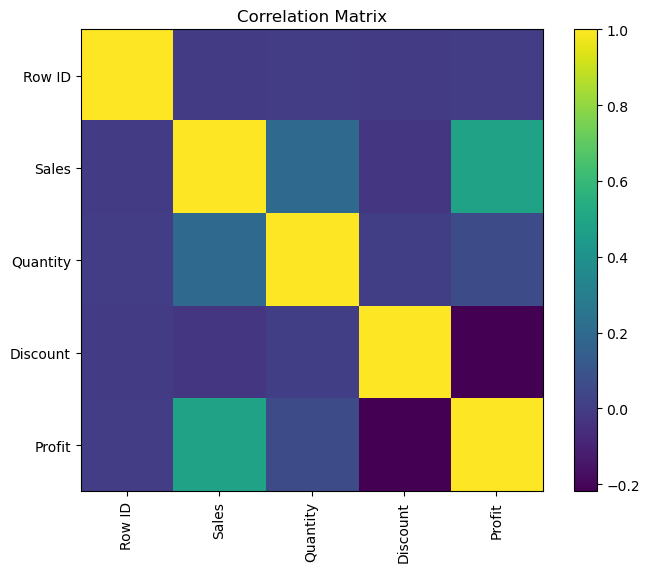

In [30]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns,)
plt.title("Correlation Matrix")
plt.show()

In [31]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [32]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day
0,1,US-2023-103800,2023-01-03,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,3
1,2,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,4
2,3,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,4
3,4,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,4
4,5,US-2023-141817,2023-01-05,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,5
